# **Bank Telemarketing Dataset -- Macroeconomics EDA Approach**

In [1]:
## Import commonly used libraries
import pandas as pd 
import numpy as np  
import sidetable
import sklearn
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob
from itertools import combinations

## Display Setting

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings('ignore')

In [3]:
file = []
data_path = Path.cwd().parent.joinpath("data", "raw")
for f in data_path.glob("*"):
    file.append(f.name)

print(file)

['.gitkeep', 'bank-additional-full.csv', 'bank-additional-names.txt', 'bank-full.csv', 'info.txt']


In [4]:
tele_df = pd.read_csv(data_path.joinpath("bank-additional-full.csv"), sep=';')
tele_df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [5]:
tele_df.shape

(41188, 21)

In [6]:
# Remove whitespaces, ., spaces and lowercase column names
tele_df.columns = tele_df.columns.str.strip().str.replace(".", " ").str.replace(" ", "_").str.lower()
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [7]:
tele_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [8]:
# Check Missing values
import sidetable
miss_df = tele_df.stb.missing()
miss_df.query("percent > 0")

,missing,total,percent


**No Missing Value in give dataset for numeric variables, will explore this.**

**Missing Attribute Values for Categorical Variables:** There are several missing values in some categorical attributes, all coded with the "unknown" label. These missing values can be treated as a possible class label or using deletion or imputation techniques.


**Social and Economic Context Data Description:**

- **emp.var.rate**: Employment variation rate - quarterly indicator (numeric)
- **cons.price.idx**: Consumer price index - monthly indicator (numeric)
- **cons.conf.idx**: Consumer confidence index - monthly indicator(numeric)
- **euribor3m**: Euribor 3-month rate - daily indicator(numeric)
- **nr.employed**: Number of employees - quarterly indicator(numeric)

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')


## **Formatting and Consistency check**

In [9]:
dtype_df = pd.DataFrame({
    'dtype': tele_df.dtypes,
    'nunique': tele_df.nunique(),
    'unique' : [tele_df[col].unique() for col in tele_df.columns]
}, index=tele_df.columns)
dtype_df

,dtype,nunique,unique
age,int64,78,"[56, 57, 37, 40, 45, 59, 41, 24, 25, 29, 35, 5..."
job,object,12,"[housemaid, services, admin., blue-collar, tec..."
marital,object,4,"[married, single, divorced, unknown]"
education,object,8,"[basic.4y, high.school, basic.6y, basic.9y, pr..."
default,object,3,"[no, unknown, yes]"
housing,object,3,"[no, yes, unknown]"
loan,object,3,"[no, yes, unknown]"
contact,object,2,"[telephone, cellular]"
month,object,10,"[may, jun, jul, aug, oct, nov, dec, mar, apr, ..."
day_of_week,object,5,"[mon, tue, wed, thu, fri]"


# **Exploratory Data Analysis -- Social Economic Context and bank related attributes**

**Social and Economic Context Data Description:**

- **emp.var.rate**: Employment variation rate - quarterly indicator (numeric)
    
    - **More on this:** Measure how much the employment changes over certian period of time(in this case, average over 3 months).

- **cons.price.idx**: Consumer price index - monthly indicator (numeric)
- **cons.conf.idx**: Consumer confidence index - monthly indicator(numeric)

**Related to bank**

- **euribor3m**: Euribor 3-month rate - daily indicator(numeric)
- **nr.employed**: Number of employees - quarterly indicator(numeric)

**Target Variable:**
- **y**: Whether the client subscribed to a term deposit (binary: 'no', 'yes')


**Target Variable**

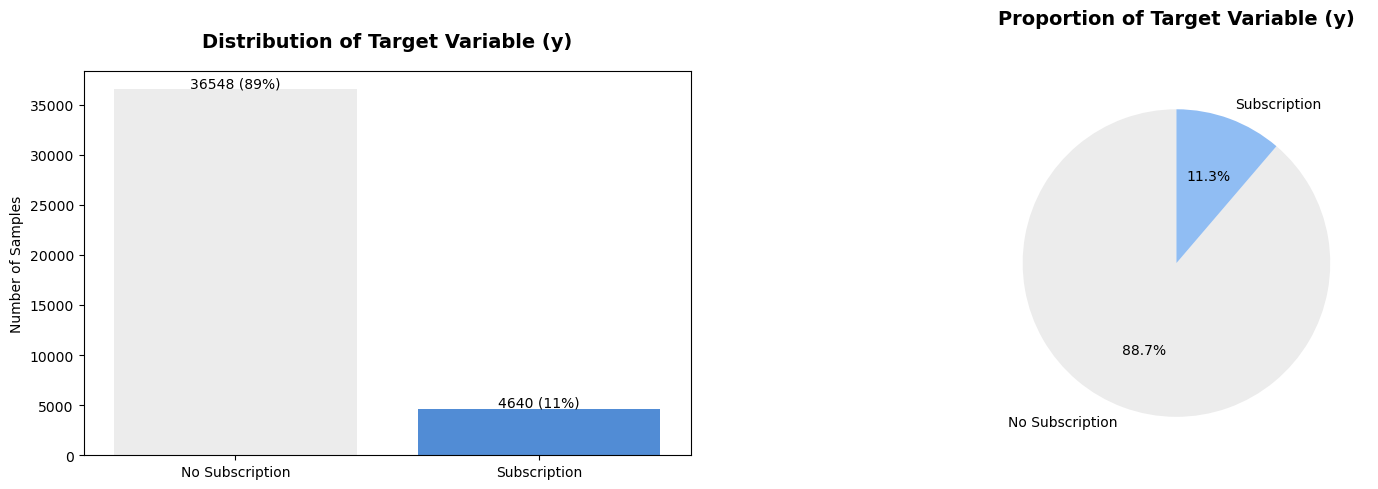

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
# Countplot for target variable
sns.countplot(
    data=tele_df, x='y', 
    order=tele_df['y'].value_counts().index, 
    palette = ['#ececec', '#3B8AEB90'],
    ax=ax[0])

ax[0].set_title('Distribution of Target Variable (y)', fontsize=14, fontweight='bold', y=1.04)
ax[0].set_xlabel('')
ax[0].set_ylabel('Number of Samples')
ax[0].set_xticks([0, 1], labels = ['No Subscription', 'Subscription'], rotation=0)

# Add percentage labels on bars
for i, v in enumerate(tele_df['y'].value_counts()):
    percentage = 100 * v / len(tele_df)
    ax[0].text(i, v + 200, f"{v} ({percentage:.0f}%)", ha='center', fontsize=10)

# Pie chart for target variable
tele_df['y'].value_counts().plot.pie(
    autopct='%1.1f%%', 
    colors = ['#ececec', "#3B8AEB90"], 
    startangle=90, labels = ['No Subscription', 'Subscription'],
    ax=ax[1])

ax[1].set_ylabel('')
ax[1].set_title('Proportion of Target Variable (y)', fontsize=14, fontweight='bold', y=1.10)

# Add layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

**Data is highly imbalanced, with a significant majority of customers not subscribing to the term deposit. This imbalance will need to be addressed in the modeling phase, possibly through techniques such as resampling or using algorithms that can handle class imbalance effectively.**

In [11]:
# Make y binary in next step:
tele_df['y_binary'] = tele_df['y'].map({'yes': 1, 'no':0})

## **Correlation Matrix**

In [55]:
numeric_cols = [col for col in tele_df.select_dtypes(['number']).columns]
cat_cols = [col for col in tele_df.select_dtypes(['object'])]

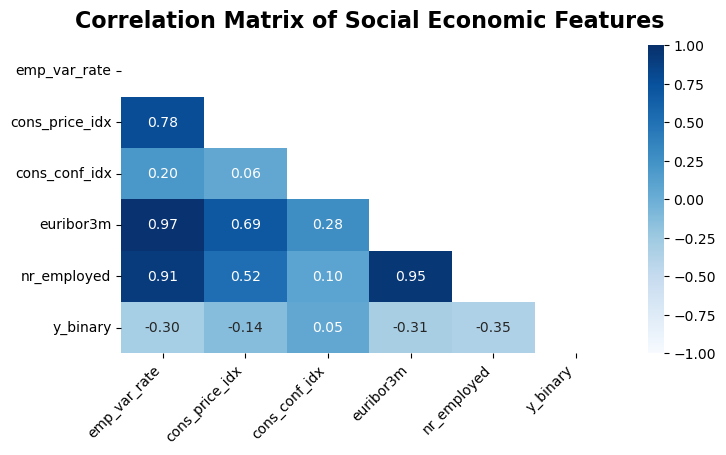

In [56]:
fig, ax = plt.subplots(figsize=(8, 4))
social_eco_df = tele_df[['emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary']]
corr_df = social_eco_df.select_dtypes(include='number').corr(method='pearson')
mask = np.triu(np.ones_like(corr_df, dtype=bool))

sns.heatmap(
    corr_df,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=-1,
    vmax=1,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')
ax.set_title('Correlation Matrix of Social Economic Features', fontsize=16, fontweight='bold', y=1.03)
plt.show()


**Strong Correlation :**

- emp_var_rate and euribor3m (0.97)
- nr_employed and euribor3m (0.95)
- nr_employed and emp_var_rate (0.91)
- cons_price_idx and emp_var_rate (0.78)

**Moderate Correlation :**

- euribor3m and cons_price_idx (0.69)
- nr_employed and cons_price_idx (0.52)

**Other are weak positive/negative correlation**

**Considering the given dataset is about customer subscribe for term deposit will depends on each customers monthly economic and social context and, undoubtedly,economic factors had an impact on customer's decision i.e., target y. Hence, decide to analyze deeper the month dimension.**

In [57]:
# Just a remainder: the observations are ordered by date (from May 2008 to November 2010.
months_arr = [
    [i, m] for i, m in enumerate(tele_df['month'])
    if i ==0 or m != tele_df['month'].iloc[i-1]
]
months_arr = np.array(months_arr)


We got:

**2008 : [0, 27690)**

**2009 : [27690, 39130)**

**2010 : [39130, 41188)**

In [58]:
# create year as column
tele_df['year'] = np.hstack(
    (np.array([2008] * (27690 - 0)),
    np.array([2009] * (39130 - 27690)),
    np.array([2010] * (41188 - 39130)))
)
tele_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp_var_rate', 'cons_price_idx',
       'cons_conf_idx', 'euribor3m', 'nr_employed', 'y', 'y_binary', 'year'],
      dtype='object')

In [59]:
list_cols = social_eco_df.columns.to_list()
list_cols.append('year')
social_eco_df = tele_df[list_cols]
social_eco_df.head()

,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,y_binary,year
0,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
1,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
2,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
3,1.1,93.994,-36.4,4.857,5191.0,no,0,2008
4,1.1,93.994,-36.4,4.857,5191.0,no,0,2008


## **Dimension Analysis**

**Dimension : emp_var_rate**

emp_var_rate : employment variation rate -- quarterly inidcator (numeric)

Just getting a general view how emp_var_rate looks throughout all 3 consecutive years.

In [87]:
def numeric_var_by_year(df, xcol, ycol, hue_col, fig=None, ax=None):
    """Plot numeric variable distribution by consecutive year"""
    if fig is  None or ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    sns.lineplot(data = df, x = xcol, y = ycol, hue=hue_col,palette='tab10', ax = ax)

    ax.set_title(f"{ycol.replace("_", " ").capitalize()}  by {hue_col.capitalize()}", fontsize=16, fontweight='bold', y=1.02)
    ax.legend(bbox_to_anchor=(1.2, 1), loc='upper right')
    plt.tight_layout()
    plt.show()

    return fig, ax

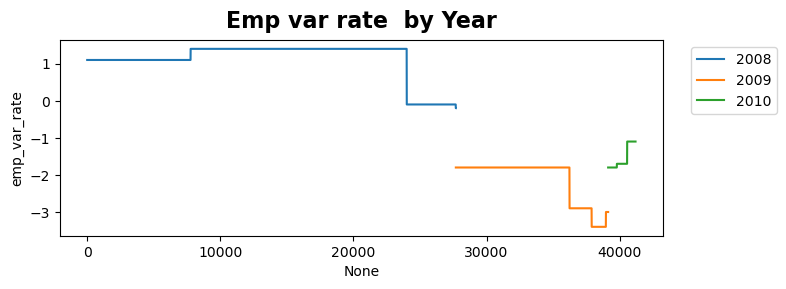

In [88]:
fig, ax = plt.subplots(figsize=(8, 3))
numeric_var_by_year(social_eco_df, social_eco_df.index, 'emp_var_rate', 'year', fig=fig, ax=ax);